# Machine Learning Algorithms - 8 New Practice Questions with Solutions

This notebook is drafted from the algorithm coverage in `T2_SUMMARY_VHA.pdf`.

## Algorithms covered

1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Regression
4. K-Nearest Neighbors Classification
5. Decision Tree Classification
6. Random Forest Classification
7. Support Vector Machine Classification
8. Model Comparison: KNN, Decision Tree, Random Forest, and SVM

Each question has its own CSV dataset, detailed problem statement, and complete solution.

## Requirement Note

Before running this notebook, install the required libraries in your Jupyter environment if they are missing:

```python
%pip install pandas numpy matplotlib scikit-learn
```

Keep this notebook and all 8 CSV files in the same folder.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

CSV_DIR = Path.cwd()
if not (CSV_DIR / "q1_machine_hours_energy_bill.csv").exists():
    CSV_DIR = Path(r"C:\Users\VISHAL\Documents\Codex\2026-07-23\referenced-chatgpt-conversation-this-is-untrusted\outputs")

CSV_DIR

WindowsPath('C:/Users/VISHAL/Music')

# Question 1: Simple Linear Regression - Machine Hours vs Energy Bill

## Dataset

CSV file: `q1_machine_hours_energy_bill.csv`

## Problem statement

A factory wants to predict its daily electricity bill using the number of machine operating hours. Build a Simple Linear Regression model.

## Tasks

1. Read the CSV file.
2. Display the first 5 records.
3. Use `MachineHours` as the independent variable and `EnergyBill` as the target variable.
4. Split the data using `test_size = 0.2` and `random_state = 42`.
5. Train a `LinearRegression` model.
6. Print slope, intercept, MSE, and R2 score.
7. Predict the energy bill for 6.5, 9, and 13 machine hours.
8. Draw actual data points and the regression line.

## Solution

Run the following cell to solve this question.

,MachineHours,EnergyBill
0,1.0,577.76
1,1.5,558.75
2,2.0,600.25
3,2.5,620.62
4,3.0,680.55


Slope: 48.9111271975181
Intercept: 509.421399086522
MSE: 404.0943924734729
R2 Score: 0.984555274417845


,MachineHours,PredictedEnergyBill
0,6.5,827.343726
1,9.0,949.621544
2,13.0,1145.266053


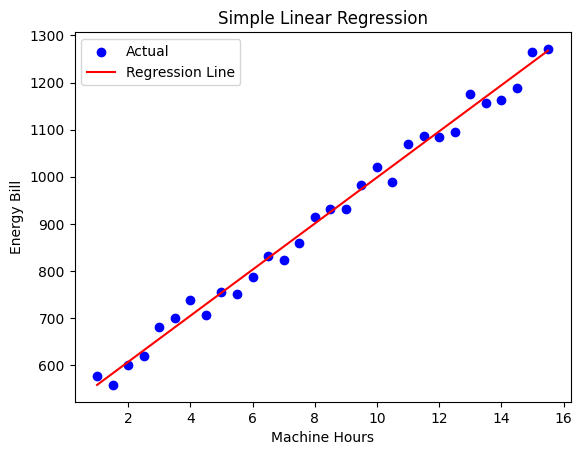

In [2]:
# Solution 1
q1 = pd.read_csv(CSV_DIR / "q1_machine_hours_energy_bill.csv")
display(q1.head())

X = q1[["MachineHours"]]
y = q1["EnergyBill"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

new_hours = pd.DataFrame({"MachineHours": [6.5, 9, 13]})
predictions = model.predict(new_hours)
display(pd.DataFrame({"MachineHours": new_hours["MachineHours"], "PredictedEnergyBill": predictions}))

plt.scatter(X, y, color="blue", label="Actual")
plt.plot(X, model.predict(X), color="red", label="Regression Line")
plt.xlabel("Machine Hours")
plt.ylabel("Energy Bill")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Question 2: Multiple Linear Regression - House Price Prediction

## Dataset

CSV file: `q2_house_price_multiple_regression.csv`

## Problem statement

A real-estate company wants to predict house price using area, bedrooms, house age, and distance from city center.

## Tasks

1. Read the dataset.
2. Display first 5 records and summary statistics.
3. Use `AreaSqFt`, `Bedrooms`, `HouseAge`, and `DistanceFromCityKm` as features.
4. Use `Price` as the target.
5. Split with `test_size = 0.2` and `random_state = 42`.
6. Train a Multiple Linear Regression model.
7. Display coefficients, intercept, MSE, and R2 score.
8. Predict price for one new house record.

## Solution

Run the following cell to solve this question.

In [3]:
# Solution 2
q2 = pd.read_csv(CSV_DIR / "q2_house_price_multiple_regression.csv")
display(q2.head())
display(q2.describe())

features = ["AreaSqFt", "Bedrooms", "HouseAge", "DistanceFromCityKm"]
X = q2[features]
y = q2["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
coef_df = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
display(coef_df)
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

new_house = pd.DataFrame([[1800, 3, 8, 6.5]], columns=features)
print("Predicted house price:", model.predict(new_house)[0])

,HouseID,AreaSqFt,Bedrooms,HouseAge,DistanceFromCityKm,Price
0,1,2302,1,29,10.1,183836.17
1,2,1425,1,35,6.0,110331.03
2,3,2463,3,12,13.0,213185.68
3,4,1116,3,5,15.5,148845.41
4,5,1428,3,29,11.8,130929.96


,HouseID,AreaSqFt,Bedrooms,HouseAge,DistanceFromCityKm,Price
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,1685.900000,2.775000,17.450000,9.820000,170869.962500
std,11.690452,588.801294,1.404891,10.040814,4.773173,49106.686351
min,1.000000,656.000000,1.000000,3.000000,1.100000,71308.540000
25%,10.750000,1148.000000,1.750000,8.750000,5.650000,148503.315000
50%,20.500000,1723.500000,3.000000,15.500000,10.100000,168878.505000
75%,30.250000,2208.000000,4.000000,28.000000,13.725000,203833.607500
max,40.000000,2589.000000,5.000000,35.000000,17.800000,279372.330000


,Feature,Coefficient
0,AreaSqFt,72.286842
1,Bedrooms,18108.929458
2,HouseAge,-1290.099935
3,DistanceFromCityKm,-2033.610162


Intercept: 41738.082113928744
MSE: 21238871.570347693
R2 Score: 0.9916265371211695
Predicted house price: 202641.91975184588


# Question 3: Polynomial Regression - Advertising Spend vs Sales

## Dataset

CSV file: `q3_advertising_polynomial_sales.csv`

## Problem statement

A business observes that increasing advertisement spend increases sales only up to a point. Use Polynomial Regression to model this non-linear relationship.

## Tasks

1. Read the dataset.
2. Use `AdSpend` as input and `Sales` as target.
3. Try polynomial degrees 1, 2, 3, 4, and 5.
4. For each degree, train a model and calculate R2 and MSE.
5. Select the best degree based on highest R2 score.
6. Predict sales for advertisement spends 45, 90, and 130.
7. Plot actual points and the best polynomial curve.

## Solution

Run the following cell to solve this question.

,AdSpend,Sales
0,5,30.90
1,10,61.85
2,15,75.92
3,20,79.15
4,25,95.99


,Degree,R2,MSE
0,1,-0.993665,1145.621343
1,2,0.947439,30.203372
2,3,0.942625,32.969623
3,4,0.949516,29.009785
4,5,0.936679,36.386436


Best degree: 4


,AdSpend,PredictedSales
0,45,154.384637
1,90,219.110611
2,130,207.688218


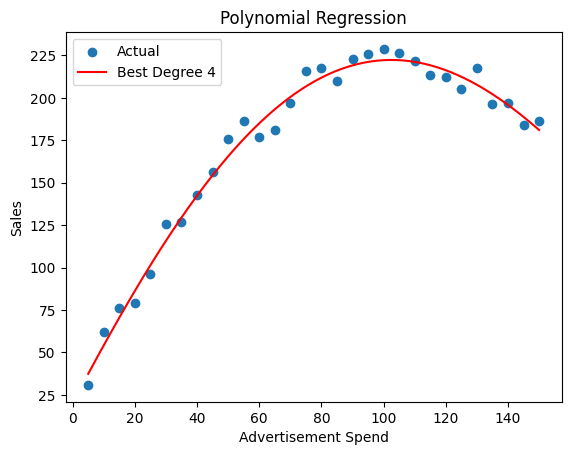

In [4]:
# Solution 3
q3 = pd.read_csv(CSV_DIR / "q3_advertising_polynomial_sales.csv")
display(q3.head())

X = q3[["AdSpend"]]
y = q3["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
best_model = None
best_degree = None
best_r2 = -999

for degree in [1, 2, 3, 4, 5]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results.append([degree, r2, mse])
    if r2 > best_r2:
        best_r2 = r2
        best_degree = degree
        best_model = model

results_df = pd.DataFrame(results, columns=["Degree", "R2", "MSE"])
display(results_df)
print("Best degree:", best_degree)

new_spend = pd.DataFrame({"AdSpend": [45, 90, 130]})
display(pd.DataFrame({"AdSpend": new_spend["AdSpend"], "PredictedSales": best_model.predict(new_spend)}))

x_curve = pd.DataFrame({"AdSpend": np.linspace(q3["AdSpend"].min(), q3["AdSpend"].max(), 200)})
plt.scatter(X, y, label="Actual")
plt.plot(x_curve, best_model.predict(x_curve), color="red", label=f"Best Degree {best_degree}")
plt.xlabel("Advertisement Spend")
plt.ylabel("Sales")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

# Question 4: KNN Classification - Loan Approval Prediction

## Dataset

CSV file: `q4_loan_approval_knn.csv`

## Problem statement

A bank wants to classify whether a loan applicant should be approved using applicant age, income, credit score, and requested loan amount.

## Tasks

1. Read the dataset.
2. Use `Age`, `AnnualIncome`, `CreditScore`, and `LoanAmount` as features.
3. Use `Approved` as target.
4. Apply feature scaling using `StandardScaler`.
5. Train KNN models for k = 1, 3, 5, 7, and 9.
6. Calculate accuracy for each k.
7. Select the best k.
8. Print confusion matrix and classification report for the best model.
9. Predict approval for two new applicants.

## Solution

Run the following cell to solve this question.

In [5]:
# Solution 4
q4 = pd.read_csv(CSV_DIR / "q4_loan_approval_knn.csv")
display(q4.head())

features = ["Age", "AnnualIncome", "CreditScore", "LoanAmount"]
X = q4[features]
y = q4["Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

results = []
best_model = None
best_k = None
best_acc = -1
for k in [1, 3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([k, acc])
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_model = model

results_df = pd.DataFrame(results, columns=["K", "Accuracy"])
display(results_df)
print("Best K:", best_k)

best_pred = best_model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, best_pred))
print("Classification Report:\n", classification_report(y_test, best_pred))

new_applicants = pd.DataFrame([[30, 65000, 720, 250000], [47, 34000, 590, 400000]], columns=features)
display(pd.DataFrame({"Prediction": best_model.predict(new_applicants)}))

,ApplicantID,Age,AnnualIncome,CreditScore,LoanAmount,Approved
0,1,54,42635,549,582496,0
1,2,32,30981,824,121262,0
2,3,36,74923,581,647347,0
3,4,59,27209,561,489589,0
4,5,57,90522,681,323432,1


,K,Accuracy
0,1,0.800000
1,3,0.866667
2,5,0.866667
3,7,0.866667
4,9,0.866667


Best K: 3
Confusion Matrix:
 [[8 1]
 [1 5]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.83      0.83      0.83         6

    accuracy                           0.87        15
   macro avg       0.86      0.86      0.86        15
weighted avg       0.87      0.87      0.87        15



,Prediction
0,0
1,0


# Question 5: Decision Tree Classification - Admission Prediction

## Dataset

CSV file: `q5_admission_decision_tree.csv`

## Problem statement

An institute wants to predict student admission using entrance marks, attendance, project count, and backlogs.

## Tasks

1. Read the dataset.
2. Split data using `test_size = 0.25` and `random_state = 42`.
3. Train Decision Tree Classifier using `criterion='entropy'`.
4. Test different `max_depth` values: 2, 3, 4, 5, and None.
5. Compare accuracy for each depth.
6. Select the best model.
7. Print confusion matrix and classification report.
8. Predict admission for two new students.

## Solution

Run the following cell to solve this question.

In [6]:
# Solution 5
q5 = pd.read_csv(CSV_DIR / "q5_admission_decision_tree.csv")
display(q5.head())

features = ["EntranceMarks", "AttendancePct", "ProjectsCompleted", "Backlogs"]
X = q5[features]
y = q5["Admitted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

results = []
best_model = None
best_depth = None
best_acc = -1
for depth in [2, 3, 4, 5, None]:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([depth, acc])
    if acc > best_acc:
        best_acc = acc
        best_depth = depth
        best_model = model

display(pd.DataFrame(results, columns=["MaxDepth", "Accuracy"]))
print("Best depth:", best_depth)

best_pred = best_model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, best_pred))
print("Classification Report:\n", classification_report(y_test, best_pred))

new_students = pd.DataFrame([[82, 88, 3, 0], [55, 62, 1, 3]], columns=features)
display(pd.DataFrame({"Prediction": best_model.predict(new_students)}))

,StudentID,EntranceMarks,AttendancePct,ProjectsCompleted,Backlogs,Admitted
0,1,63,76,1,2,0
1,2,38,69,2,3,0
2,3,94,53,4,4,1
3,4,85,82,4,0,1
4,5,89,53,3,1,0


,MaxDepth,Accuracy
0,2.0,0.866667
1,3.0,0.866667
2,4.0,0.866667
3,5.0,0.866667
4,NaN,1.000000


Best depth: None
Confusion Matrix:
 [[13  0]
 [ 0  2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         2

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



,Prediction
0,1
1,0


# Question 6: Random Forest Classification - Employee Retention

## Dataset

CSV file: `q6_employee_retention_random_forest.csv`

## Problem statement

A company wants to predict whether an employee will leave the company using satisfaction, salary, weekly hours, experience, and promotion history.

## Tasks

1. Read the dataset.
2. Use Random Forest Classifier.
3. Test `n_estimators` values 25, 50, 75, 100, and 150.
4. Use `criterion='entropy'` and `random_state=42`.
5. Calculate accuracy for each number of trees.
6. Select the best model.
7. Display feature importance.
8. Predict whether two new employees will leave.

## Solution

Run the following cell to solve this question.

In [7]:
# Solution 6
q6 = pd.read_csv(CSV_DIR / "q6_employee_retention_random_forest.csv")
display(q6.head())

features = ["SatisfactionScore", "MonthlySalary", "WeeklyHours", "ExperienceYears", "PromotionLast2Years"]
X = q6[features]
y = q6["LeftCompany"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

results = []
best_model = None
best_trees = None
best_acc = -1
for trees in [25, 50, 75, 100, 150]:
    model = RandomForestClassifier(n_estimators=trees, criterion="entropy", random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([trees, acc])
    if acc > best_acc:
        best_acc = acc
        best_trees = trees
        best_model = model

display(pd.DataFrame(results, columns=["Trees", "Accuracy"]))
print("Best number of trees:", best_trees)

importance_df = pd.DataFrame({"Feature": features, "Importance": best_model.feature_importances_}).sort_values("Importance", ascending=False)
display(importance_df)

new_employees = pd.DataFrame([[0.35, 36000, 58, 2, 0], [0.82, 85000, 42, 8, 1]], columns=features)
display(pd.DataFrame({"Prediction_LeftCompany": best_model.predict(new_employees)}))

,EmpID,SatisfactionScore,MonthlySalary,WeeklyHours,ExperienceYears,PromotionLast2Years,LeftCompany
0,1,0.81,47962,65,17,1,0
1,2,0.38,101720,62,16,0,1
2,3,0.55,67081,41,6,1,0
3,4,0.61,111846,60,18,0,0
4,5,0.48,67372,42,13,0,0


,Trees,Accuracy
0,25,0.95
1,50,0.95
2,75,0.95
3,100,0.95
4,150,0.95


Best number of trees: 25


,Feature,Importance
0,SatisfactionScore,0.470167
2,WeeklyHours,0.218503
1,MonthlySalary,0.191743
3,ExperienceYears,0.082104
4,PromotionLast2Years,0.037482


,Prediction_LeftCompany
0,1
1,0


# Question 7: SVM Classification - Customer Churn Prediction

## Dataset

CSV file: `q7_customer_churn_svm.csv`

## Problem statement

A telecom company wants to predict customer churn using tenure, monthly charges, support calls, and contract score.

## Tasks

1. Read the dataset.
2. Use `TenureMonths`, `MonthlyCharges`, `SupportCalls`, and `ContractScore` as features.
3. Use `Churn` as target.
4. Apply feature scaling.
5. Train SVM with RBF kernel.
6. Test C values: 0.1, 1, 5, and 10.
7. Compare accuracy for each C value.
8. Print confusion matrix and classification report for the best model.
9. Predict churn for two new customers.

## Solution

Run the following cell to solve this question.

In [8]:
# Solution 7
q7 = pd.read_csv(CSV_DIR / "q7_customer_churn_svm.csv")
display(q7.head())

features = ["TenureMonths", "MonthlyCharges", "SupportCalls", "ContractScore"]
X = q7[features]
y = q7["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

results = []
best_model = None
best_c = None
best_acc = -1
for c_value in [0.1, 1, 5, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=c_value, random_state=42))
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([c_value, acc])
    if acc > best_acc:
        best_acc = acc
        best_c = c_value
        best_model = model

display(pd.DataFrame(results, columns=["C", "Accuracy"]))
print("Best C:", best_c)

best_pred = best_model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, best_pred))
print("Classification Report:\n", classification_report(y_test, best_pred))

new_customers = pd.DataFrame([[8, 2600, 6, 2], [48, 900, 1, 8]], columns=features)
display(pd.DataFrame({"Prediction_Churn": best_model.predict(new_customers)}))

,CustomerID,TenureMonths,MonthlyCharges,SupportCalls,ContractScore,Churn
0,1,40,445.34,6,10,1
1,2,27,1264.54,3,3,0
2,3,38,1349.99,0,8,0
3,4,23,713.39,8,4,0
4,5,46,530.64,0,7,1


,C,Accuracy
0,0.1,0.777778
1,1.0,0.777778
2,5.0,0.666667
3,10.0,0.666667


Best C: 0.1
Confusion Matrix:
 [[5 4]
 [0 9]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.69      1.00      0.82         9

    accuracy                           0.78        18
   macro avg       0.85      0.78      0.77        18
weighted avg       0.85      0.78      0.77        18



,Prediction_Churn
0,1
1,0


# Question 8: Model Comparison - KNN, Decision Tree, Random Forest, and SVM

## Dataset

CSV file: `q8_credit_risk_model_comparison.csv`

## Problem statement

A finance company wants to compare four classification algorithms for predicting customer default risk.

## Tasks

1. Read the dataset.
2. Use `Age`, `AnnualIncome`, `CreditScore`, `DebtRatio`, and `EmploymentYears` as features.
3. Use `DefaultRisk` as target.
4. Train and test these models on the same train-test split:
   - KNN with `k=5`
   - Decision Tree with `criterion='entropy'`
   - Random Forest with `n_estimators=100`
   - SVM with RBF kernel and `C=1`
5. Use scaling for KNN and SVM.
6. Calculate accuracy for all models.
7. Display the best algorithm.
8. Predict default risk for one new customer using the best model.

## Solution

Run the following cell to solve this question.

In [9]:
# Solution 8
q8 = pd.read_csv(CSV_DIR / "q8_credit_risk_model_comparison.csv")
display(q8.head())

features = ["Age", "AnnualIncome", "CreditScore", "DebtRatio", "EmploymentYears"]
X = q8[features]
y = q8["DefaultRisk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

models = {
    "KNN (k=5)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1, random_state=42))])
}

results = []
best_name = None
best_model = None
best_acc = -1

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])
    if acc > best_acc:
        best_acc = acc
        best_name = name
        best_model = model

comparison_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy"]).sort_values("Accuracy", ascending=False)
display(comparison_df)
print("Best algorithm:", best_name)

new_customer = pd.DataFrame([[35, 58000, 690, 0.32, 6]], columns=features)
print("Predicted default risk:", best_model.predict(new_customer)[0])

,CustomerID,Age,AnnualIncome,CreditScore,DebtRatio,EmploymentYears,DefaultRisk
0,1,42,38447,540,0.29,9,0
1,2,60,119065,718,0.19,14,0
2,3,24,120265,680,0.47,13,0
3,4,25,34835,826,0.34,16,0
4,5,65,45969,515,0.17,19,0


,Algorithm,Accuracy
2,Random Forest,0.869565
0,KNN (k=5),0.826087
3,SVM (RBF),0.826087
1,Decision Tree,0.652174


Best algorithm: Random Forest
Predicted default risk: 0
